In [2]:
# Print the exact column names available in the dataset
print(df.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELE

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup plotting style
sns.set_theme(style="whitegrid")

# Get absolute path to the dataset
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
data_folder = os.path.join(project_root, 'data')

# Dynamically locate the CSV file inside the data directory
extracted_files = os.listdir(data_folder)
csv_files = [file for file in extracted_files if file.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV file found in the data directory.")

csv_file_path = os.path.join(data_folder, csv_files[0])

# Load the credit card dataset
df = pd.read_csv(csv_file_path, sep=',')
print(f"Dataset successfully loaded. Shape: {df.shape}")

Dataset successfully loaded. Shape: (307511, 122)


In [6]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


Missing Values

In [8]:
# 1. Identify columns by type dynamically
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
text_cols = df.select_dtypes(include=['object', 'str']).columns

# 2. Fill missing values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
for col in text_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values cleaned!")
print("Remaining null values:", df.isnull().sum().sum())

Missing values cleaned!
Remaining null values: 0


Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder

# Find text columns directly
text_cols = df.select_dtypes(include=['object', 'str']).columns

# Convert text columns into numbers
for col in text_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col].astype(str))

print("Text columns successfully converted to numbers!")

Text columns successfully converted to numbers!


Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

# 1. Select all numerical columns in the current dataframe
all_numeric = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Isolate only the features we want to scale (excluding IDs and TARGET)
features_to_scale = [col for col in all_numeric if col not in ['SK_ID_CURR', 'TARGET']]

# 3. Apply the standard scaler to normalize the features
scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Data standardization finished successfully!")
print("\nFirst 5 rows of a few standardized columns:")
print(df[features_to_scale[:3]].head())

Data standardization finished successfully!

First 5 rows of a few standardized columns:
   NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR
0           -0.324395     1.388015     -0.717914
1           -0.324395    -0.720370     -0.717914
2            3.082659     1.388015      1.392925
3           -0.324395    -0.720370     -0.717914
4           -0.324395     1.388015     -0.717914


In [13]:
# Calculate how much each variable relates to the TARGET
# (Values closer to 1 or -1 mean a stronger relationship)
correlations = df.corr()['TARGET'].sort_values(ascending=False)

print("Top 5 variables most related to Credit Default:")
print(correlations.head(6)) # Shows the top positive correlations

print("\nTop 5 variables that protect against Credit Default:")
print(correlations.tail(5)) # Shows the top negative correlations

Top 5 variables most related to Credit Default:
TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
NAME_EDUCATION_TYPE            0.054699
Name: TARGET, dtype: float64

Top 5 variables that protect against Credit Default:
AMT_GOODS_PRICE   -0.039623
DAYS_EMPLOYED     -0.044932
EXT_SOURCE_1      -0.098887
EXT_SOURCE_3      -0.155892
EXT_SOURCE_2      -0.160295
Name: TARGET, dtype: float64


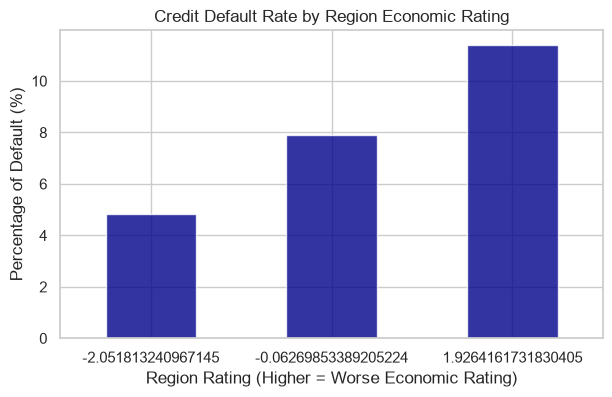

In [15]:
# Group by region rating and calculate the percentage of credit default
region_analysis = df.groupby('REGION_RATING_CLIENT_W_CITY')['TARGET'].mean() * 100

# Plot the business metrics
plt.figure(figsize=(7, 4))
region_analysis.plot(kind='bar', color='darkblue', alpha=0.8)

plt.title('Credit Default Rate by Region Economic Rating')
plt.xlabel('Region Rating (Higher = Worse Economic Rating)')
plt.ylabel('Percentage of Default (%)')
plt.xticks(rotation=0)
plt.show()

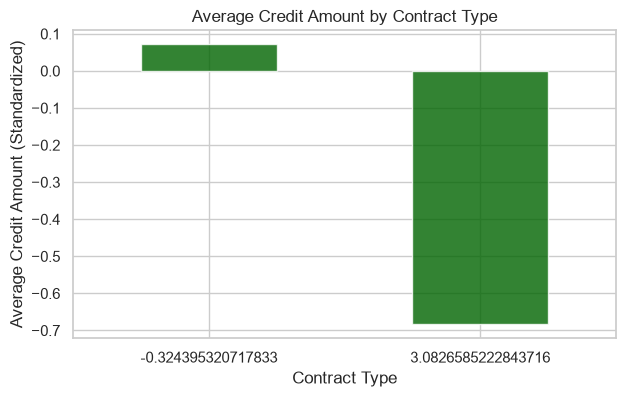

In [16]:
# Calculate the average credit amount for each contract type
contract_analysis = df.groupby('NAME_CONTRACT_TYPE')['AMT_CREDIT'].mean()

# Plot the business metrics
plt.figure(figsize=(7, 4))
contract_analysis.plot(kind='bar', color='darkgreen', alpha=0.8)

plt.title('Average Credit Amount by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Average Credit Amount (Standardized)')
plt.xticks(rotation=0)
plt.show()

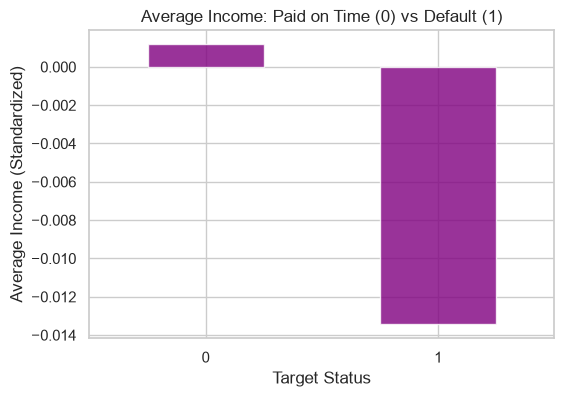

In [17]:
# Calculate the average income for clients who paid (0) vs those who defaulted (1)
income_analysis = df.groupby('TARGET')['AMT_INCOME_TOTAL'].mean()

# Plot the business metrics
plt.figure(figsize=(6, 4))
income_analysis.plot(kind='bar', color='purple', alpha=0.8)

plt.title('Average Income: Paid on Time (0) vs Default (1)')
plt.xlabel('Target Status')
plt.ylabel('Average Income (Standardized)')
plt.xticks(rotation=0)
plt.show()